# The Sentiment Playground

**25882 AI-powered Investment and Risk Management** · warm-up for Lecture 7

---

## Can a computer tell how you feel?

Sort of. Badly. In ways that are much more interesting than "yes" or "no".

This notebook is a toy box. Nothing in it is about finance, nothing is assessed, and
you cannot break anything. Type your own text in, see what comes out, and spend most
of your energy trying to **make the models fail**.

That last part is not a joke. By the end you will have found a pair of sentences
containing exactly the same two facts that score **opposite signs** purely because of
the order the facts appear in. Once you have seen that with your own eyes, everything
in Lecture 7 about sentiment scores being *models* rather than *measurements* will
feel obvious.

### The eight rooms

| | Room | You will |
| --- | --- | --- |
| 1 | The playground | paste any text and score it three ways |
| 2 | Inside a lexicon | open the dictionary up and read it |
| 3 | The knobs | find the literal rules — caps, `!!!`, emoji |
| 4 | Break the model | sarcasm, negation, and the word-order trick |
| 5 | The shape of a story | plot the emotional arc of a novel |
| 6 | One number isn't enough | split a sentence that has two opinions in it |
| 7 | The modern way | run a neural network in three lines |
| 8 | Same fact, different spin | rewrite a headline without lying |

Roughly an hour. Rooms 1–4 are the core; 5–8 stand alone if you are short of time.

### Setup

Everything is `pip`-installable and small. Room 7 downloads a model (~250 MB) and
**skips itself politely** if your network says no.

In [1]:
# --- setup: run me first --------------------------------------------------
import sys, subprocess

def ensure(pkg, mod=None):
    '''Import if present, else pip install. Handles locked-down environments.'''
    try:
        __import__(mod or pkg)
        return True
    except ImportError:
        pass
    print(f"installing {pkg} ...")
    for extra in ([], ["--user"], ["--break-system-packages"]):
        r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg] + extra,
                           capture_output=True, text=True)
        if r.returncode == 0:
            return True
    print(f"   could not install {pkg}. Run this in a terminal:")
    print(f"      pip install {pkg}")
    return False

for p, m in [("vaderSentiment", "vaderSentiment"), ("textblob", "textblob"),
             ("plotly", "plotly"), ("ipywidgets", "ipywidgets")]:
    ensure(p, m)

import re, warnings
warnings.filterwarnings("ignore")
import numpy as np
import plotly.graph_objects as go
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

vader = SentimentIntensityAnalyzer()

# house colours, so the charts look like the lecture slides
NAVY, RED, BLUE, TINT, GREY = "#123F69", "#C11B17", "#0041C2", "#E2EBF4", "#7A8794"

def style(fig, title="", height=380, **kw):
    fig.update_layout(template="plotly_white", title_text=title,
                      font=dict(family="Helvetica, Arial, sans-serif", size=13),
                      title_font=dict(size=16, color=NAVY),
                      height=height, margin=dict(l=60, r=30, t=60, b=50), **kw)
    return fig

print("ready — no restart needed")

ready — no restart needed


## Room 1 — The playground

Two analysers, both dictionary-based, both instant.

**VADER** was built for social media. It knows emoji, slang and `!!!`. It returns a
`compound` score from −1 to +1.

**TextBlob** returns `polarity` (−1 to +1) and also `subjectivity` (0 = factual,
1 = opinionated). The subjectivity number is underrated and we will use it in Room 8.

Here is the entire API. This is genuinely all there is to it.

In [2]:
text = "I absolutely loved this. Best thing all week."

print("VADER   ", vader.polarity_scores(text))
print("TextBlob", TextBlob(text).sentiment)

VADER    {'neg': 0.0, 'neu': 0.387, 'pos': 0.613, 'compound': 0.8891}
TextBlob Sentiment(polarity=0.85, subjectivity=0.55)


VADER's dictionary gives you four numbers: the share of the text it reads as
`neg`/`neu`/`pos`, and then `compound`, a single summary normalised to −1…+1. The
compound score is the one everybody quotes, so it is the one we will use.

<details>
<summary><b>Where does <code>compound</code> actually come from? (click to expand)</b></summary>

It is two steps: **add up**, then **squash**.

**Step 1 — add up the valences.** Every word found in the lexicon contributes its
score $v_i$ (roughly −4 to +4). The hand-written rules then adjust those values before
summing:

| Rule | Effect | Constant |
| --- | --- | --- |
| booster word (`very`, `extremely`) | add to magnitude | $\pm 0.293$ |
| dampener (`kinda`, `slightly`) | subtract from magnitude | $\mp 0.293$ |
| ALL-CAPS word, in a mixed-case sentence | add to magnitude | $\pm 0.733$ |
| negation within 3 words (`not`, `never`) | flip and shrink | $\times\,(-0.74)$ |
| `but` in the sentence | reweight clauses | $\times 0.5$ before, $\times 1.5$ after |
| each `!` (up to three) | add to the total | $+0.292$ |
| `?` marks | add to the total | $+0.18$ to $+0.96$ |

Call the result $x$ — the raw sum. It is unbounded: a long, enthusiastic paragraph can
reach $x = 30$ or more.

**Step 2 — squash it into −1…+1.** VADER does not divide by the word count. It applies

$$\text{compound} \;=\; \frac{x}{\sqrt{x^{2} + \alpha}}, \qquad \alpha = 15$$

then clamps to $[-1, 1]$. This curve is close to linear for small $x$ and flattens
hard as $x$ grows — $x=2$ gives 0.46, $x=5$ gives 0.79, $x=10$ gives 0.93, $x=20$
gives 0.98.

**Two consequences worth carrying with you.**

*The denominator is a constant, not a length.* Because $\alpha$ is fixed at 15 rather
than scaling with the text, longer text accumulates more valence and saturates. This
is exactly the trap waiting in Room 5, where a 400-word chunk of a novel comes back at
+0.9993.

*It is arithmetic you can check.* `good` is 1.9 in the lexicon, so

$$\text{compound} = \frac{1.9}{\sqrt{1.9^{2}+15}} = \frac{1.9}{\sqrt{18.61}} = 0.4404$$

which is precisely what Room 3 will report. Add one `!` and the sum becomes
$1.9 + 0.292 = 2.192$, giving $2.192/\sqrt{19.80} = 0.4926$. Shout it —
$1.9 + 0.733 = 2.633$ — and you get $0.5622$.

No training, no parameters fitted to data. Somebody wrote those constants down.

</details>

Now wrap both in one function and give ourselves a picture.

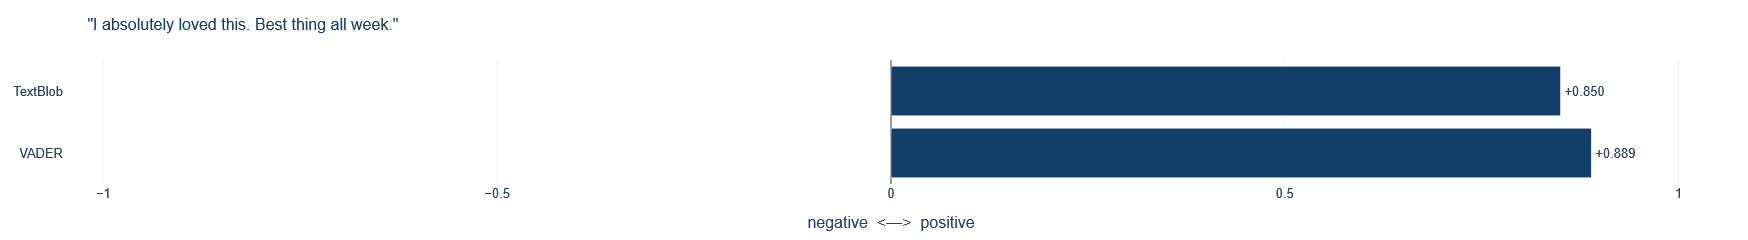

subjectivity (TextBlob): 0.55   (0 = factual, 1 = opinionated)


In [3]:
def score(text: str) -> dict:
    '''Run every analyser we have on one string.'''
    tb = TextBlob(text).sentiment
    return {
        "VADER": vader.polarity_scores(text)["compound"],
        "TextBlob": tb.polarity,
        "_subjectivity": tb.subjectivity,
    }

def show(text: str, title=None):
    '''Score a string and draw it.'''
    s = score(text)
    names = [k for k in s if not k.startswith("_")]
    vals = [s[k] for k in names]
    fig = go.Figure(go.Bar(
        x=vals, y=names, orientation="h",
        marker_color=[NAVY if v >= 0 else RED for v in vals],
        text=[f"{v:+.3f}" for v in vals], textposition="outside",
    ))
    fig.update_xaxes(range=[-1.05, 1.05], title_text="negative  <—>  positive",
                     zeroline=True, zerolinecolor="#999")
    style(fig, title or f'"{text[:70]}{"..." if len(text) > 70 else ""}"',
          height=240, showlegend=False).show()
    print(f"subjectivity (TextBlob): {s['_subjectivity']:.2f}   "
          f"(0 = factual, 1 = opinionated)")
    return s

_ = show("I absolutely loved this. Best thing all week.")

### Optional: check the arithmetic yourself

If you expanded the fold-out above, this reproduces `compound` from the raw lexicon
scores. It is the whole model, in four lines.

In [4]:
import math

def compound_by_hand(raw_sum, alpha=15):
    return raw_sum / math.sqrt(raw_sum ** 2 + alpha)

lexicon = vader.lexicon
checks = [
    ("good",                lexicon["good"],           "just the word"),
    ("good!",               lexicon["good"] + 0.292,   "one '!' adds 0.292"),
    ("good!!!",             lexicon["good"] + 3*0.292, "three '!' add 0.876"),
    ("This movie was GOOD", lexicon["good"] + 0.733,   "CAPS adds 0.733"),
]

print(f"{'text':22s}{'raw sum':>9s}{'by hand':>10s}{'VADER':>10s}   note")
for text, raw, note in checks:
    mine = compound_by_hand(raw)
    theirs = vader.polarity_scores(text)["compound"]
    flag = "ok" if abs(mine - theirs) < 1e-4 else "MISMATCH"
    print(f"{text:22s}{raw:>9.3f}{mine:>+10.4f}{theirs:>+10.4f}   {note} [{flag}]")

text                    raw sum   by hand     VADER   note
good                      1.900   +0.4404   +0.4404   just the word [ok]
good!                     2.192   +0.4926   +0.4926   one '!' adds 0.292 [ok]
good!!!                   2.776   +0.5826   +0.5826   three '!' add 0.876 [ok]
This movie was GOOD       2.633   +0.5622   +0.5622   CAPS adds 0.733 [ok]


### Your turn

Type anything. A message you sent this morning, a review you left, a comment you saw.
Press **Score it**.

Things worth trying:

* something you meant sarcastically
* something with an emoji
* a sentence with a `but` in the middle
* your own name (yes, really)

In [5]:
try:
    import ipywidgets as W
    from IPython.display import display, clear_output

    box = W.Textarea(value="Honestly? Not what I expected 🙄",
                     placeholder="type anything...",
                     layout=W.Layout(width="640px", height="80px"))
    btn = W.Button(description="Score it", button_style="primary")
    out = W.Output()

    def _click(_):
        with out:
            clear_output(wait=True)
            show(box.value)

    btn.on_click(_click)
    display(W.VBox([box, btn, out]))
    _click(None)

except Exception as exc:
    # ---- fallback: no widgets available. Edit the string and re-run. ----
    print(f"(widgets unavailable: {type(exc).__name__} — using plain variables)\n")
    my_text = "Honestly? Not what I expected 🙄"
    _ = show(my_text)

## Room 2 — Inside a lexicon

Here is the thing nobody tells you: VADER is **a spreadsheet**. Somebody sat down and
gave a score to each of several thousand words. That is the entire model. There is no
training, no neural network, no learning.

You can just... open it.

In [6]:
lex = vader.lexicon
print(f"VADER's dictionary has {len(lex):,} entries.\n")

print("A few you might recognise:")
for w in ["good", "great", "amazing", "fine", "okay", "bad", "awful", "catastrophic"]:
    print(f"   {w:14s} {lex.get(w, 'NOT IN DICTIONARY')}")

VADER's dictionary has 7,506 entries.

A few you might recognise:
   good           1.9
   great          3.1
   amazing        2.8
   fine           0.8
   okay           0.9
   bad            -2.5
   awful          -2.0
   catastrophic   -2.2


### It speaks internet

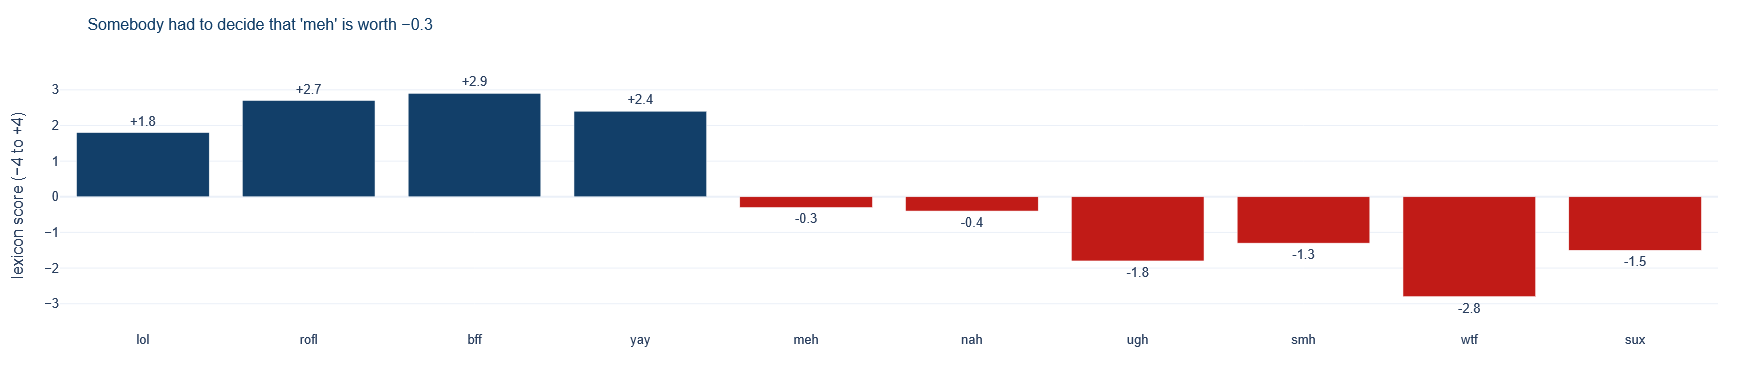

In [7]:
slang = ["lol", "rofl", "bff", "yay", "meh", "nah", "ugh", "smh", "wtf", "sux"]
found = {w: lex[w] for w in slang if w in lex}

fig = go.Figure(go.Bar(
    x=list(found.keys()), y=list(found.values()),
    marker_color=[NAVY if v >= 0 else RED for v in found.values()],
    text=[f"{v:+.1f}" for v in found.values()], textposition="outside",
))
fig.update_yaxes(title_text="lexicon score (−4 to +4)")
style(fig, "Somebody had to decide that 'meh' is worth −0.3", showlegend=False).show()

`bff` = +2.9. `rofl` = +2.7. `smh` = −1.3. A human being made each of those calls, and
you are now downstream of their judgement every time you use this tool.

That is not a criticism. It is the point of the exercise: **a lexicon is a pile of
opinions with a version number.**

### Does it know your words?

Search for anything. Slang, jargon, a word from your first language, your own name.
Most searches will come back empty — the dictionary is 7,500 words and English has
rather more than that.

In [8]:
def lookup(word: str):
    w = word.strip().lower()
    if w in lex:
        v = lex[w]
        mood = "positive" if v > 0 else "negative" if v < 0 else "neutral"
        print(f"'{w}'  ->  {v:+.1f}   ({mood})")
    else:
        print(f"'{w}'  ->  not in the dictionary. VADER reads it as neutral.")
        print(f"          Any sentence relying on '{w}' to carry feeling will score flat.")

try:
    import ipywidgets as W
    from IPython.display import display, clear_output
    tb_ = W.Text(value="cooked", description="word:", layout=W.Layout(width="380px"))
    ob_ = W.Output()
    def _go(change=None):
        with ob_:
            clear_output(wait=True); lookup(tb_.value)
    tb_.observe(lambda c: _go() if c["name"] == "value" else None, names="value")
    display(W.VBox([tb_, ob_])); _go()
except Exception:
    for w in ["cooked", "mid", "slay", "banger", "shambolic"]:
        lookup(w)

Try `cooked`, `mid`, `slay`, `banger`. VADER was assembled in 2014 and it shows.

> **The lesson that transfers:** every lexicon has a vintage. A tool built on 2014
> internet English will quietly score 2026 internet English as neutral — not wrong,
> just *silent*. And silence looks exactly like neutrality in the output.

### Mini-game: guess the score

Before running the cell, write down your guess for each word on a scale of −4 to +4.

In [9]:
quiz = ["mediocre", "brilliant", "adequate", "obsessed", "whatever", "grateful"]
print("word            VADER says")
print("-" * 30)
for w in quiz:
    print(f"{w:14s}  {lex.get(w, 0.0):+.1f}")
print("\nHow many were you within 1.0 of?")

word            VADER says
------------------------------
mediocre        +0.0
brilliant       +2.8
adequate        +0.9
obsessed        -0.7
whatever        +0.0
grateful        +2.0

How many were you within 1.0 of?


## Room 3 — The knobs

VADER is not *only* a spreadsheet. On top of the word scores sit a handful of
hand-written rules. Unlike a neural network, you can find out exactly what they are —
by poking it.

Each row below is the same word with one thing changed.

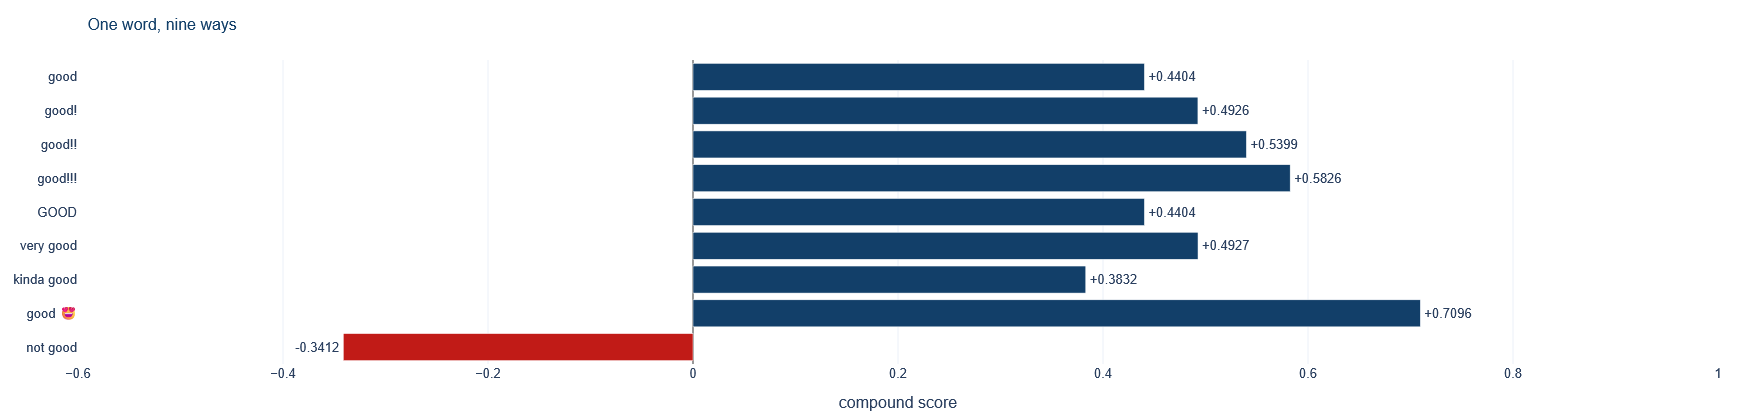

In [10]:
ladder = ["good", "good!", "good!!", "good!!!", "GOOD", "very good", "kinda good",
          "good 😍", "not good"]
vals = [vader.polarity_scores(t)["compound"] for t in ladder]

fig = go.Figure(go.Bar(
    x=vals, y=ladder, orientation="h",
    marker_color=[NAVY if v >= 0 else RED for v in vals],
    text=[f"{v:+.4f}" for v in vals], textposition="outside",
))
fig.update_xaxes(range=[-0.6, 1.0], zeroline=True, zerolinecolor="#999",
                 title_text="compound score")
fig.update_yaxes(autorange="reversed")
style(fig, "One word, nine ways", height=420, showlegend=False).show()

So the rules are:

* **exclamation marks** add intensity, and they stack (up to a cap of three)
* **capitals** add intensity
* **degree words** — `very` amplifies, `kinda` dampens
* **emoji** count as words with their own scores
* **negation** flips the sign

All of that was written by hand. You could read the source code on the train home.

### The gotcha

Try to predict this one before you run it. Does shouting harder always help?

In [11]:
caps = ["This movie was good", "This movie was GOOD", "THIS MOVIE WAS GOOD"]
for t in caps:
    print(f"  {t:24s} {vader.polarity_scores(t)['compound']:+.4f}")

  This movie was good      +0.4404
  This movie was GOOD      +0.5622
  THIS MOVIE WAS GOOD      +0.4404


### Shouting one word works. Shouting everything does nothing.

`GOOD` in a normal sentence scores **+0.5622**. The same sentence entirely in capitals
drops back to **+0.4404** — precisely where it started.

The rule is written to fire on *contrast*: capitals only count as emphasis when there
is something lower-case to be emphatic against. `ALL CAPS` throughout has no contrast,
so the rule switches itself off.

Nobody would guess that from the documentation. You found it by poking, which is how
most people find out what a model actually does.

## Room 4 — Break the model

Now the fun part. Below are sentences chosen to be hard. **Write down your own
judgement for each one first** — positive, negative or neutral — then reveal.

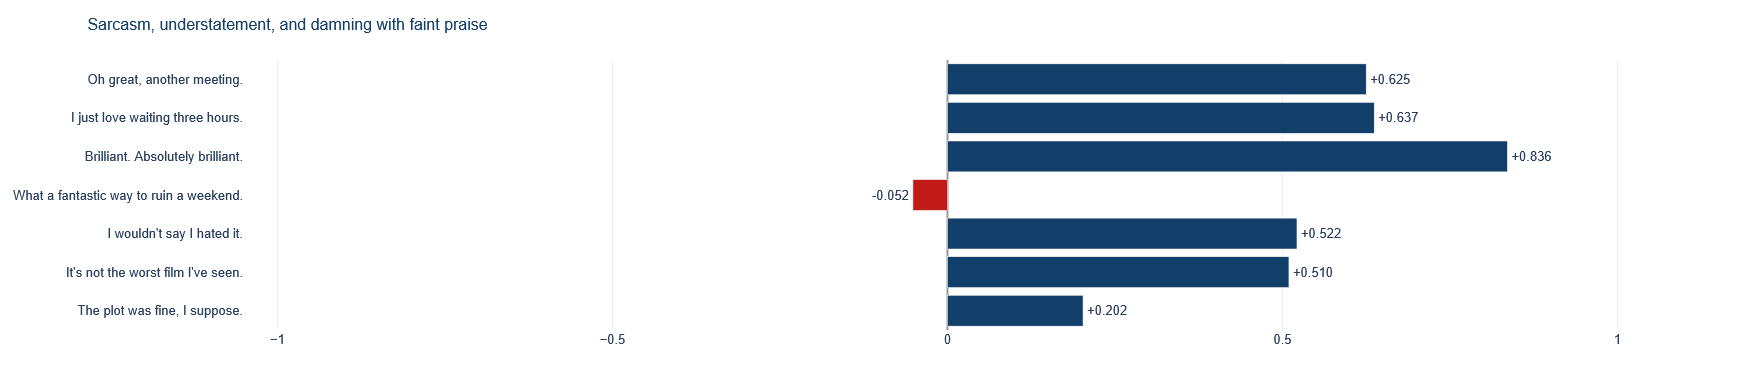

In [12]:
tricky = [
    "Oh great, another meeting.",
    "I just love waiting three hours.",
    "Brilliant. Absolutely brilliant.",
    "What a fantastic way to ruin a weekend.",
    "I wouldn't say I hated it.",
    "It's not the worst film I've seen.",
    "The plot was fine, I suppose.",
]

vals = [vader.polarity_scores(t)["compound"] for t in tricky]
fig = go.Figure(go.Bar(
    x=vals, y=tricky, orientation="h",
    marker_color=[NAVY if v >= 0 else RED for v in vals],
    text=[f"{v:+.3f}" for v in vals], textposition="outside",
))
fig.update_xaxes(range=[-1.05, 1.15], zeroline=True, zerolinecolor="#999")
fig.update_yaxes(autorange="reversed")
style(fig, "Sarcasm, understatement, and damning with faint praise",
      height=380, showlegend=False).show()

Every sarcastic sentence scores **confidently positive**. Not uncertain — confident.

This is worth sitting with. The model is not hedging or flagging low confidence; it
returns +0.62 for *"Oh great, another meeting"* with exactly the same conviction it
brings to a sincere compliment. **A wrong answer and a right answer look identical in
the output.**

Sarcasm is hard because the words say one thing and the *context* inverts it, and a
dictionary has no context. It sees `great` and `love` and does its job.

### The word-order trick

This is the one. Same two facts, same two opinions, one clause swapped.

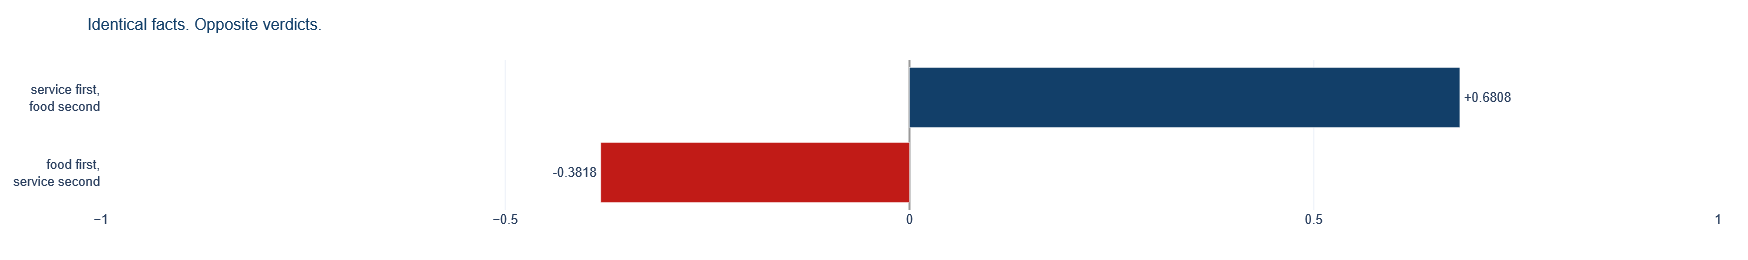

-0.3818   The food was great but the service was terrible.
+0.6808   The service was terrible but the food was great.

Gap: 1.0626 — a swing of more than one full point.


In [13]:
pair = [
    "The food was great but the service was terrible.",
    "The service was terrible but the food was great.",
]
vals = [vader.polarity_scores(t)["compound"] for t in pair]

fig = go.Figure(go.Bar(
    x=vals, y=["food first,<br>service second", "service first,<br>food second"],
    orientation="h", marker_color=[RED, NAVY],
    text=[f"{v:+.4f}" for v in vals], textposition="outside",
))
fig.update_xaxes(range=[-1.0, 1.0], zeroline=True, zerolinecolor="#999")
style(fig, "Identical facts. Opposite verdicts.", height=260, showlegend=False).show()

for t, v in zip(pair, vals):
    print(f"{v:+.4f}   {t}")
print(f"\nGap: {abs(vals[0]-vals[1]):.4f} — a swing of more than one full point.")

### Why this matters more than the sarcasm

VADER has a rule that says: *when a sentence contains `but`, downweight what came
before it and upweight what came after.* Which is a perfectly sensible rule about how
English works. Whatever follows the `but` is usually the speaker's real point.

Applied here, it means the model is answering a subtly different question from the one
you asked. You asked *"was this restaurant good?"*. It answered *"which half of the
sentence was emphasised?"*.

> **Hold on to this for the lecture.** The number is not a measurement of the world.
> It is the output of a set of choices somebody made — and a choice as small as
> clause ordering moved it by more than a full point.

### Challenge

Write a sentence that scores **above +0.5** but that any human would read as
unambiguously bad news.

The scoreboard ranks by how badly you fooled it: your stated intent versus what the
model said.

In [14]:
scoreboard = []

def fool(sentence: str, intent: str, name: str = "me"):
    '''intent: 'positive', 'negative' or 'neutral' - what YOU think it means.'''
    v = vader.polarity_scores(sentence)["compound"]
    target = {"positive": 1.0, "negative": -1.0, "neutral": 0.0}[intent]
    gap = abs(target - v)
    scoreboard.append({"name": name, "sentence": sentence,
                       "intent": intent, "vader": round(v, 4), "gap": round(gap, 4)})
    # a genuine fooling means the model landed on the OPPOSITE side, not merely flat
    opposite = (intent == "negative" and v > 0.3) or (intent == "positive" and v < -0.3)
    verdict = ("FOOLED IT" if opposite
               else "went flat" if abs(v) < 0.15
               else "partly fooled" if gap > 0.8 else "no luck")
    print(f"{verdict:14s} you said {intent:8s} | VADER said {v:+.4f} | gap {gap:.4f}")
    return gap

# worked examples to beat
fool("Oh brilliant, the server is down again.", "negative", "example")
fool("I am thrilled to announce that we are all being made redundant.",
     "negative", "example")

# --- your turn: replace the sentence, keep the intent honest ---
fool("Replace this text with your own attempt.", "negative", "your name here")

FOOLED IT      you said negative | VADER said +0.5859 | gap 1.5859
FOOLED IT      you said negative | VADER said +0.4404 | gap 1.4404
went flat      you said negative | VADER said +0.0000 | gap 1.0000


1.0

In [15]:
import pandas as pd
board = (pd.DataFrame(scoreboard).sort_values("gap", ascending=False)
           .reset_index(drop=True))
print("SCOREBOARD — biggest gap wins\n")
print(board.to_string(index=False, max_colwidth=58))

SCOREBOARD — biggest gap wins

          name                                                   sentence   intent  vader    gap
       example                    Oh brilliant, the server is down again. negative 0.5859 1.5859
       example I am thrilled to announce that we are all being made re... negative 0.4404 1.4404
your name here                   Replace this text with your own attempt. negative 0.0000 1.0000


## Room 5 — The shape of a story

Kurt Vonnegut had a theory that stories come in a small number of emotional shapes,
and that you could draw them. *Man in Hole*: things are fine, things get bad, things
get better. *Boy Meets Girl*. *Cinderella*.

He could not test it. We can, in about fifteen lines.

We will take a whole novel from Project Gutenberg — public domain, free, no
registration — split it into sentences, score every sentence, and plot the average
through the book.

In [16]:
import urllib.request

BOOKS = {
    "Alice in Wonderland": "https://raw.githubusercontent.com/GITenberg/"
                           "Alice-s-Adventures-in-Wonderland_11/master/11.txt",
    "Frankenstein":        "https://raw.githubusercontent.com/GITenberg/"
                           "Frankenstein_84/master/84.txt",
}

def load_book(url: str) -> str:
    raw = urllib.request.urlopen(
        urllib.request.Request(url, headers={"User-Agent": "playground"}),
        timeout=60).read().decode("utf-8", "ignore")
    # Gutenberg wraps every book in a licence header and footer. Cut them off.
    s = re.search(r"\*\*\*\s*START OF TH[EIS]+ PROJECT GUTENBERG.*?\*\*\*", raw, re.S | re.I)
    e = re.search(r"\*\*\*\s*END OF TH[EIS]+ PROJECT GUTENBERG.*?\*\*\*", raw, re.S | re.I)
    body = raw[s.end():e.start()] if (s and e) else raw
    return re.sub(r"\s+", " ", body).strip()

TITLE = "Alice in Wonderland"
book = load_book(BOOKS[TITLE])
print(f"{TITLE}: {len(book.split()):,} words")

Alice in Wonderland: 26,460 words


### One decision that changes everything

Before plotting, a trap worth walking into deliberately.

The obvious move is to cut the book into 50 chunks and score each chunk as one string.
Try it, and every chunk comes back at roughly ±1.0 — a flat line of extremes.

The reason is that VADER's compound score is a **normalised sum**. Feed it 400 words
and enough sentiment words accumulate to pin the score against the ceiling. It is not
broken; it is being used at the wrong unit.

The fix is to score **sentence by sentence** and average within each chunk. Same text,
same model, completely different picture.

In [17]:
sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", book)
             if len(s.strip().split()) >= 3]
print(f"{len(sentences):,} sentences")

# the wrong way
chunk_as_one = " ".join(sentences[:120])
print(f"\n120 sentences scored as ONE string  : "
      f"{vader.polarity_scores(chunk_as_one)['compound']:+.4f}   <- pinned")

# the right way
per_sentence = np.array([vader.polarity_scores(s)["compound"] for s in sentences[:120]])
print(f"the same 120, scored individually   : {per_sentence.mean():+.4f}   <- usable")

926 sentences

120 sentences scored as ONE string  : +0.9993   <- pinned
the same 120, scored individually   : +0.0869   <- usable


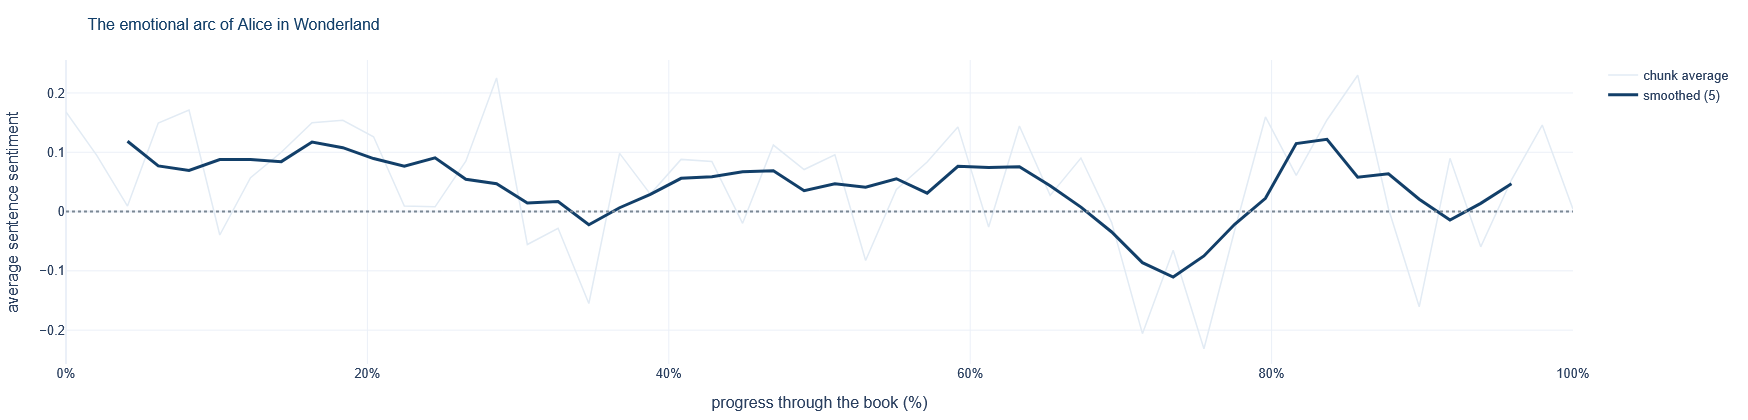

most cheerful moment : 86% in   (+0.230)
bleakest moment      : 76% in   (-0.231)


In [18]:
scores = np.array([vader.polarity_scores(s)["compound"] for s in sentences])

N_CHUNKS = 50
arc = np.array([scores[i].mean() for i in np.array_split(np.arange(len(scores)), N_CHUNKS)])

K = 5                                     # smoothing window
smooth = np.convolve(arc, np.ones(K) / K, mode="same")
smooth[:K // 2] = np.nan; smooth[-(K // 2):] = np.nan
x = np.linspace(0, 100, N_CHUNKS)

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=arc, mode="lines", name="chunk average",
                         line=dict(color=TINT, width=1.5)))
fig.add_trace(go.Scatter(x=x, y=smooth, mode="lines", name=f"smoothed ({K})",
                         line=dict(color=NAVY, width=3)))
fig.add_hline(y=0, line_color=GREY, line_dash="dot")
fig.update_xaxes(title_text="progress through the book (%)", ticksuffix="%")
fig.update_yaxes(title_text="average sentence sentiment")
style(fig, f"The emotional arc of {TITLE}", height=420).show()

print(f"most cheerful moment : {x[arc.argmax()]:.0f}% in   ({arc.max():+.3f})")
print(f"bleakest moment      : {x[arc.argmin()]:.0f}% in   ({arc.min():+.3f})")

### Two things to try

1. **Change `TITLE` to `"Frankenstein"`** and re-run the last three cells. It is a
   markedly gloomier book and the arc should show it. Does it?
2. **Change `K`.** At `K=1` you see noise; at `K=15` you see almost nothing. Somewhere
   between is a shape you would be willing to defend in public.

That second one is not a cosmetic choice. **The amount of smoothing determines what
story you claim the data tells**, and there is no correct answer sitting in the text
waiting to be found. Pick a value, then check your conclusion still holds at half and
double it. If it doesn't, the conclusion was about the smoothing.

## Room 6 — One number isn't enough

Back to the restaurant. *"The food was great but the service was terrible."*

A single number was always going to struggle, because there are **two opinions about
two different things**. Averaging them into one figure throws away the only
information anyone actually wanted.

The professional version of this is called *aspect-based sentiment analysis*. The
five-line version splits on conjunctions and scores the pieces.

In [19]:
def by_clause(text: str):
    parts = [p.strip(" ,.") for p in re.split(r"\b(?:but|however|although|though|whereas|yet)\b",
                                              text, flags=re.I) if p.strip(" ,.")]
    return [(p, vader.polarity_scores(p)["compound"]) for p in parts]

demo = "The food was great but the service was terrible."
print(f"whole sentence : {vader.polarity_scores(demo)['compound']:+.4f}\n")
for part, v in by_clause(demo):
    print(f"  {v:+.4f}   {part}")

whole sentence : -0.3818

  +0.6249   The food was great
  -0.4767   the service was terrible


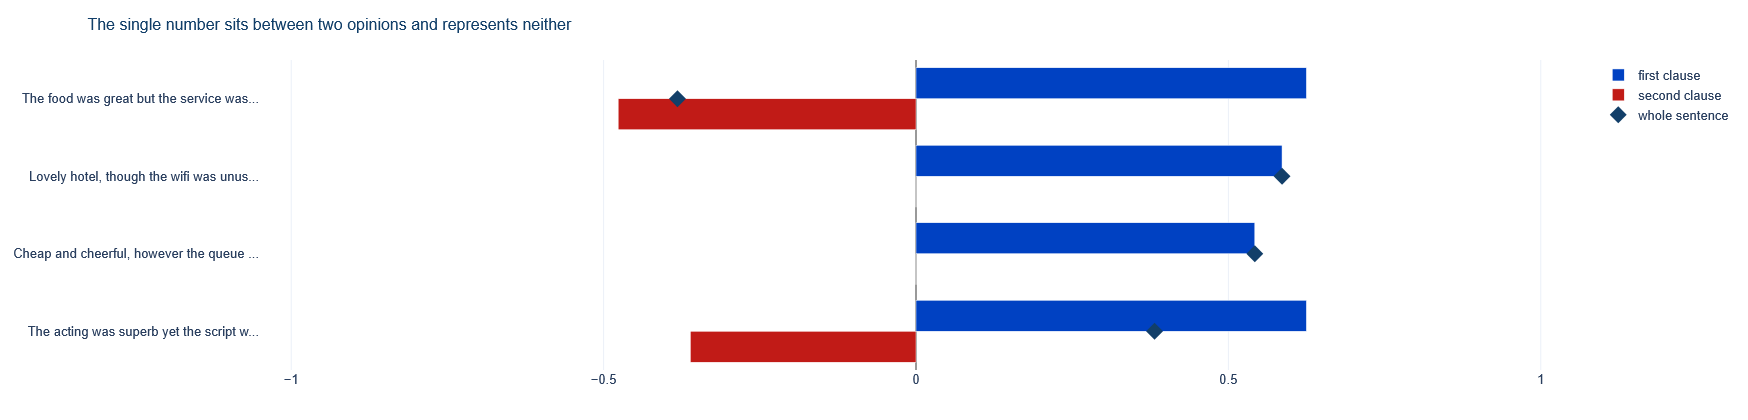

In [20]:
reviews = [
    "The food was great but the service was terrible.",
    "Lovely hotel, though the wifi was unusable.",
    "Cheap and cheerful, however the queue was enormous.",
    "The acting was superb yet the script was a mess.",
]

whole = [vader.polarity_scores(r)["compound"] for r in reviews]
firsts = [by_clause(r)[0][1] for r in reviews]
lasts = [by_clause(r)[-1][1] for r in reviews]
labels = [r[:38] + "..." for r in reviews]

fig = go.Figure()
fig.add_trace(go.Bar(y=labels, x=firsts, orientation="h", name="first clause",
                     marker_color=BLUE))
fig.add_trace(go.Bar(y=labels, x=lasts, orientation="h", name="second clause",
                     marker_color=RED))
fig.add_trace(go.Scatter(y=labels, x=whole, mode="markers", name="whole sentence",
                         marker=dict(color=NAVY, size=13, symbol="diamond")))
fig.update_xaxes(range=[-1.05, 1.05], zeroline=True, zerolinecolor="#999")
fig.update_yaxes(autorange="reversed")
style(fig, "The single number sits between two opinions and represents neither",
      height=420, barmode="group").show()

The diamond is what you would have reported. The bars are what was actually said.

Notice that the diamond is rarely near the middle of the two bars — it is pulled
towards the second clause by the `but` rule from Room 4. So the summary number is not
even a fair average of the two opinions. It is a weighted one, weighted by a rule you
did not choose.

### Emotion, not just polarity

There is another way one number falls short: *angry* and *sad* are both negative, and
you would treat a customer differently depending which one you were looking at.

Below is a small emotion lexicon. It is deliberately tiny and deliberately editable —
**this is what every emotion tool is, underneath**. Add your own words to it.

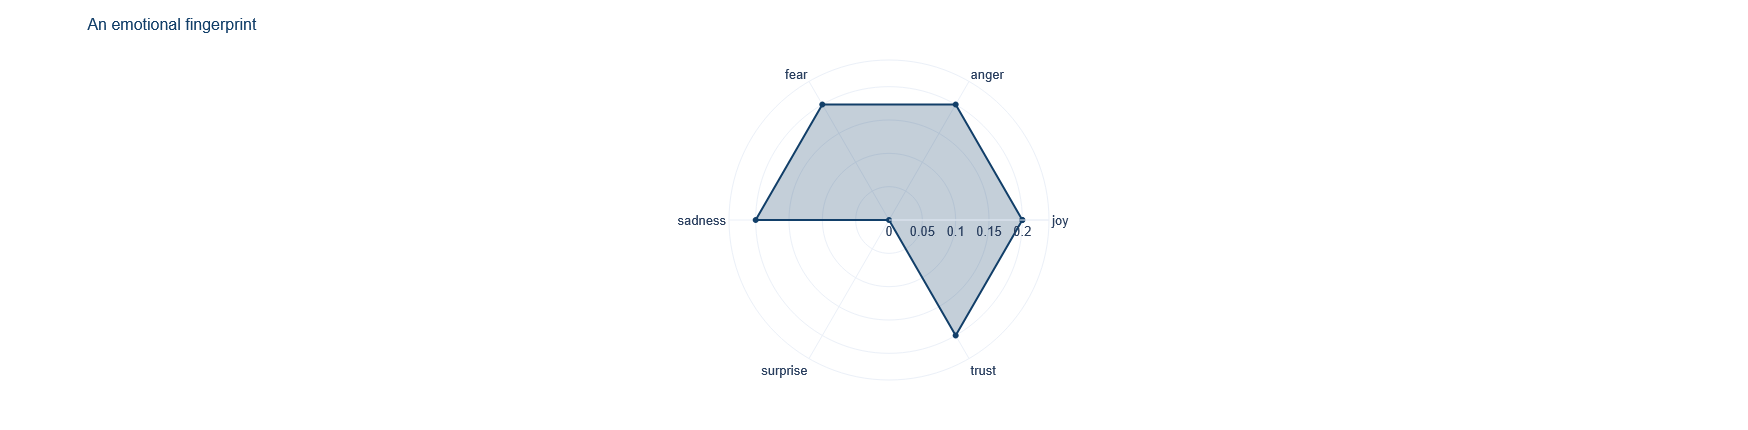

"I was absolutely thrilled at first, then genuinely worried, and by the end just disappointed and honestly quite angry about the whole thing."

VADER's one number: -0.4019
...which tells you the direction and nothing else.


In [21]:
EMOTIONS = {
    "joy":      ["happy", "delighted", "thrilled", "joy", "wonderful", "love", "great",
                 "excellent", "pleased", "glad", "brilliant", "fantastic", "enjoy"],
    "anger":    ["angry", "furious", "outraged", "hate", "disgusted", "annoyed",
                 "appalling", "unacceptable", "livid", "insulting", "ridiculous"],
    "fear":     ["afraid", "scared", "terrified", "worried", "anxious", "nervous",
                 "panic", "dread", "frightening", "alarming", "uncertain"],
    "sadness":  ["sad", "unhappy", "miserable", "disappointed", "sorry", "grief",
                 "lonely", "hopeless", "regret", "heartbroken", "gloomy"],
    "surprise": ["surprised", "shocked", "unexpected", "astonished", "sudden",
                 "amazed", "stunned", "remarkable", "extraordinary"],
    "trust":    ["trust", "reliable", "honest", "confident", "assured", "safe",
                 "dependable", "certain", "proven", "consistent"],
}

def emotions(text: str) -> dict:
    words = re.findall(r"[a-z']+", text.lower())
    counts = {e: sum(w.startswith(tuple(k[:5] for k in kws)) for w in words)
              for e, kws in EMOTIONS.items()}
    total = sum(counts.values()) or 1
    return {e: c / total for e, c in counts.items()}

sample = ("I was absolutely thrilled at first, then genuinely worried, and by the end "
          "just disappointed and honestly quite angry about the whole thing.")
prof = emotions(sample)

fig = go.Figure(go.Scatterpolar(r=list(prof.values()) + [list(prof.values())[0]],
                                theta=list(prof.keys()) + [list(prof.keys())[0]],
                                fill="toself", line=dict(color=NAVY),
                                fillcolor="rgba(18,63,105,0.25)"))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, max(prof.values()) * 1.2])))
style(fig, "An emotional fingerprint", height=430, showlegend=False).show()

print(f'"{sample}"\n')
print(f"VADER's one number: {vader.polarity_scores(sample)['compound']:+.4f}")
print("...which tells you the direction and nothing else.")

## Room 7 — The modern way

Everything so far has been dictionaries and hand-written rules. The modern approach is
a neural network trained on hundreds of thousands of labelled examples — it reads a
whole sentence at once, so word order and context are, in principle, within reach.

The remarkable part is how little code it takes.

⚠️ **This cell downloads about 250 MB.** If your network blocks it the cell will say
so and skip; nothing below depends on it.

In [22]:
transformer = None
try:
    ensure("transformers"); ensure("torch")
    from transformers import pipeline
    transformer = pipeline("sentiment-analysis",
                           model="distilbert-base-uncased-finetuned-sst-2-english")
    print("loaded\n")
    print(transformer("I absolutely loved this."))
except Exception as exc:
    print(f"Skipping Room 7 — {type(exc).__name__}: {str(exc)[:110]}")
    print("This is normal on a restricted network. Room 8 works fine without it.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

loaded

[{'label': 'POSITIVE', 'score': 0.9998764991760254}]


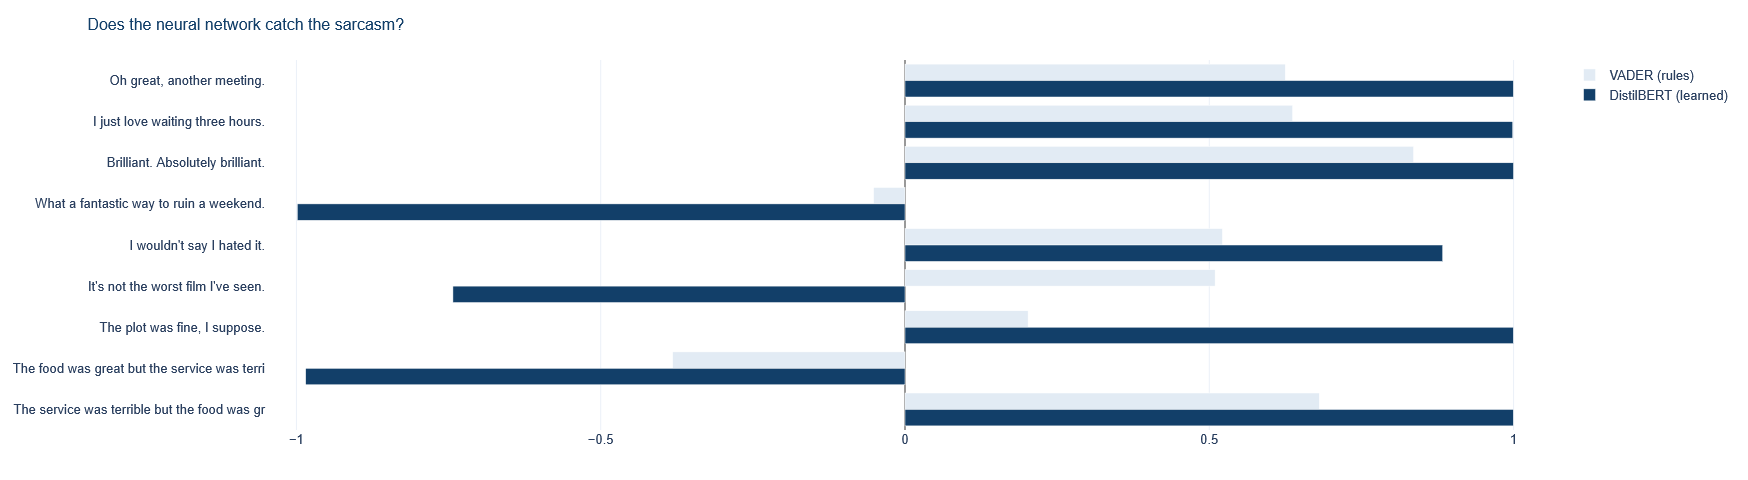

In [23]:
if transformer is not None:
    def t_score(text):
        r = transformer(text[:512])[0]
        return r["score"] if r["label"] == "POSITIVE" else -r["score"]

    battle = tricky + pair
    v_vals = [vader.polarity_scores(t)["compound"] for t in battle]
    t_vals = [t_score(t) for t in battle]

    fig = go.Figure()
    fig.add_trace(go.Bar(y=[b[:44] for b in battle], x=v_vals, orientation="h",
                         name="VADER (rules)", marker_color=TINT))
    fig.add_trace(go.Bar(y=[b[:44] for b in battle], x=t_vals, orientation="h",
                         name="DistilBERT (learned)", marker_color=NAVY))
    fig.update_xaxes(range=[-1.05, 1.05], zeroline=True, zerolinecolor="#999")
    fig.update_yaxes(autorange="reversed")
    style(fig, "Does the neural network catch the sarcasm?", height=480,
          barmode="group").show()
else:
    print("(Room 7 skipped — see the cell above.)")

### Read the result carefully

The transformer will get *some* of these right that VADER got wrong — it has seen
enough sarcastic film reviews to have learned a few patterns.

But look at the word-order pair at the bottom, and at any it still gets wrong. Two
things are worth noticing:

1. It also returns **high confidence when it is wrong**. Being learned rather than
   rule-based does not buy you calibrated uncertainty.
2. When it *is* wrong, you have no idea why. With VADER you could open the dictionary
   and read the rule. Here there is nothing to read.

That trade — accuracy for auditability — is the one you will keep meeting for the
rest of this subject, and there is no setting where it goes away.

## Room 8 — Same fact, different spin

One last thing, and it is the one with teeth.

Below is a single event described four ways. The underlying fact does not change. Only
the words do.

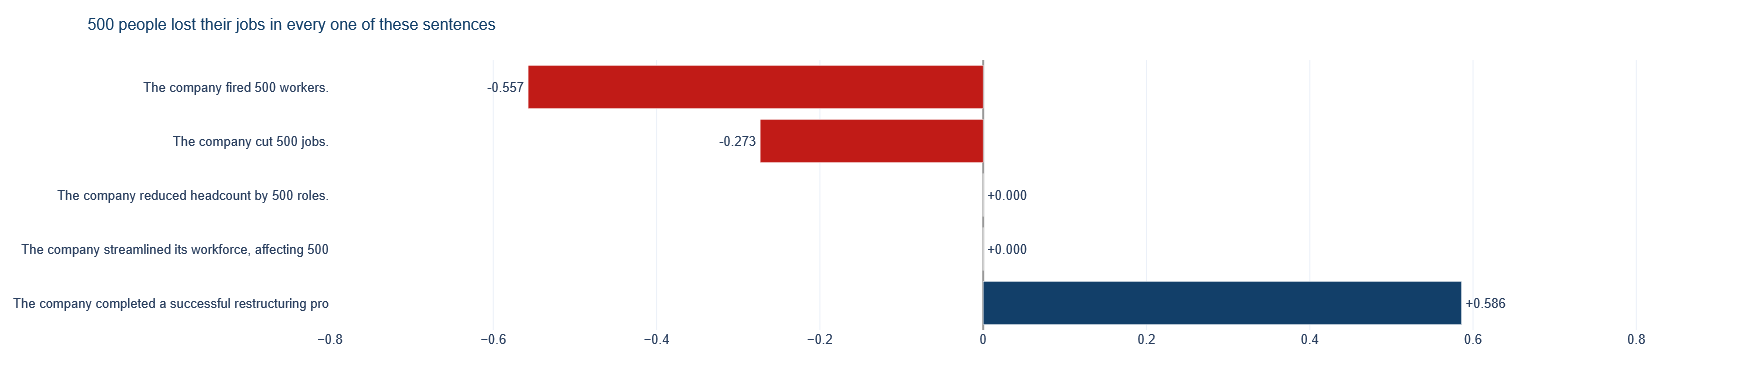

  -0.557  (subjectivity 0.00)  The company fired 500 workers.
  -0.273  (subjectivity 0.00)  The company cut 500 jobs.
  +0.000  (subjectivity 0.00)  The company reduced headcount by 500 roles.
  +0.000  (subjectivity 0.00)  The company streamlined its workforce, affecting 500 positions.
  +0.586  (subjectivity 0.95)  The company completed a successful restructuring programme and reduced headcount by 500 roles.


In [25]:
same_fact = [
    "The company fired 500 workers.",
    "The company cut 500 jobs.",
    "The company reduced headcount by 500 roles.",
    "The company streamlined its workforce, affecting 500 positions.",
    "The company completed a successful restructuring programme and reduced headcount by 500 roles.",
]

v_vals = [vader.polarity_scores(t)["compound"] for t in same_fact]
subj = [TextBlob(t).sentiment.subjectivity for t in same_fact]

fig = go.Figure(go.Bar(
    x=v_vals, y=[t[:52] for t in same_fact], orientation="h",
    marker_color=[NAVY if v >= 0 else RED for v in v_vals],
    text=[f"{v:+.3f}" for v in v_vals], textposition="outside",
))
fig.update_xaxes(range=[-0.8, 0.9], zeroline=True, zerolinecolor="#999")
fig.update_yaxes(autorange="reversed")
style(fig, "500 people lost their jobs in every one of these sentences",
      height=380, showlegend=False).show()

for t, v, s in zip(same_fact, v_vals, subj):
    print(f"  {v:+.3f}  (subjectivity {s:.2f})  {t}")

The same event runs from clearly negative to clearly positive without a single false
statement being made. Nobody lied. The words were simply chosen.

Look at where the euphemisms landed. *"Reduced headcount"* and *"streamlined its
workforce"* score **exactly 0.000** — not mildly negative, not softened, but
**invisible**. VADER has no entry for `headcount` or `streamlined`, so as far as the
model is concerned nothing happened at all.

That is the more effective trick, and the more troubling one. Spinning a score
positive takes obviously cheerful words that a reader can see through. Making the
event *disappear from the measurement* only takes vocabulary the dictionary has never
met — and to a downstream model, a score of zero and a genuinely uneventful day are
the same thing.

### Your turn, and then the uncomfortable question

Take a neutral fact and write five versions running from bleak to glowing.

In [26]:
your_versions = [
    "Rent in the city rose 12% this year.",
    "Rent in the city climbed 12% this year.",
    "The rental market strengthened 12% this year.",
    "Landlords saw returns improve 12% this year.",
    "The property market delivered a robust 12% performance this year.",
]

for t in your_versions:
    v = vader.polarity_scores(t)["compound"]
    print(f"  {v:+.3f}   {t}")

spread = (max(vader.polarity_scores(t)["compound"] for t in your_versions)
          - min(vader.polarity_scores(t)["compound"] for t in your_versions))
print(f"\nSpread achieved on one unchanged fact: {spread:.3f}")

  +0.000   Rent in the city rose 12% this year.
  +0.000   Rent in the city climbed 12% this year.
  +0.421   The rental market strengthened 12% this year.
  +0.440   Landlords saw returns improve 12% this year.
  +0.340   The property market delivered a robust 12% performance this year.

Spread achieved on one unchanged fact: 0.440


### The uncomfortable question

You have just learned to move a sentiment score without changing any facts.

Somewhere there is a company whose press releases are written by people who know this,
and whose investors run sentiment models that do not. Press-release tone is a genuine
input to real trading strategies. So:

* If you can shift a score by choosing words, **what is a corporate sentiment score
  actually measuring** — the health of the business, or the skill of its
  communications team?
* You now have a tool that makes writing more persuasive without making it more true.
  Where is the line, and who decides?

No answer required today. But you should not be able to un-notice it, and it is the
reason Lecture 7 spends a whole section on validating a text signal rather than
building one.

## What now

You have found, with your own hands:

* a lexicon is a spreadsheet of opinions with a vintage
* the rules on top of it are literal, inspectable and occasionally surprising
* sarcasm defeats it completely, and it stays confident while being wrong
* **the same two facts score opposite signs depending on their order**
* the unit you score at — sentence or chunk — changes the answer more than the model does
* one number cannot hold two opinions
* a neural network fixes some of this and makes the rest unauditable
* and a score can be moved without changing a single fact

Lecture 7 takes exactly these observations and asks what happens when someone puts
money behind the number. The lecture's argument is that **a sentiment score is a model,
not a measurement** — four decisions, each of which can flip the sign of a result.

You have now flipped a sign yourself, with two clauses and a `but`. The rest is detail.

**Next:** `Lec07a_-_Three_Scorers.ipynb`, where the same tools meet 4,845 sentences
that sixteen human beings argued about.